One step:\
Using numbers predict price movements as regression\
Using numbers predict price movement as classification\
Using everything predict price movement as regression\
Using everything predict price movement as classification

Three step:\
Predict sentiment using just text and price price movement\
Predict surprise using just text and vol change\
Incorporate numerical data and predict price movement as regression\
Incorporate numerical data and predict price movement as Classifcation

Standards of comparison:\
A model that chooses randomly\
A model that just uses the numerical data\
Models that just use everyhting one step\
Model that uses just text one step (from three step)\
Three step model\
Random assigment


In [38]:
import seaborn as sns
import sklearn
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import torch
import tensorflow as tf
import torch.nn as nn
import numpy as np
import sklearn
from sklearn.utils import shuffle
df = pd.read_csv("ProcessedTitanData.csv", index_col=False)
df = df[df["trailingPEG1Y"].notna()]
df = df[df["marketCap"].notna()]
df = df[df["enterpriseVal"].notna()]
df = df[df["PERatio"].notna()]
df = df[df["PBRatio"].notna()]
df["startVal"] =(df["nextBid931"] + df["nextAsk931"])/2
df["endVal"] =(df["nextBid1500"] + df["nextAsk1500"])/2
df["diffVal"] = df["endVal"] - df["startVal"]
df["diffScale"] = (df["endVal"]/df["startVal"])-1
df["diffSign"] = (df["diffScale"]>0).astype(int)
df["volScale"] = ((df["volNextDay"] + df["volNext2Day"] + df["volNext3Day"])/3)/df["volLast3MonthCloseAvg"]

In [30]:
print(df["category"][:10])
categories = df["category"]
list_of_lists = [s.split('/') for s in categories]
print(list_of_lists[:10])
flattened = [item for sublist in list_of_lists for item in sublist]
count_none_only = sum(1 for sublist in list_of_lists if 'stock split' in sublist)
print(count_none_only)
print(100*count_none_only/len(list_of_lists))
print(list(sorted(set(flattened))))

0        none/offering
1    none/fda approval
2                 none
3                 none
4                 none
5    none/fda approval
6                 none
7                 none
8    none/fda approval
9                 none
Name: category, dtype: object
[['none', 'offering'], ['none', 'fda approval'], ['none'], ['none'], ['none'], ['none', 'fda approval'], ['none'], ['none'], ['none', 'fda approval'], ['none']]
15
0.01794086690268874
['AI', 'IPO', 'acquisition', 'buyback', 'clinical trial', 'conferences', 'covid-19', 'dividends', 'earnings', 'fda approval', 'high short', 'management', 'none', 'offering', 'partnership', 'private placement', 'stock split']


## Use numbers predict vol move as regression

In [33]:
print(df.columns)
df_test = df.iloc[:7941].copy()
df_trainval = df.iloc[7941:].copy()
df_val = df_trainval.sample(frac=0.1)
df_train = df_trainval.drop(df_val.index)
train_X = df_train.iloc[:, [9,10,11,12,13,17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,]]
train_y = np.log(df_train["volScale"])
val_X = df_val.iloc[:, [9,10,11,12,13,17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,]]
val_y = np.log(df_val["volScale"])
test_X = df_test.iloc[:, [9,10,11,12,13,17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,]]
test_y = np.log(df_test["volScale"])
#print(len(train_X["first4SIC"].unique()))
train_X_normalized = train_X
for column in train_X.columns:
    train_X_normalized[column] = (train_X[column] - train_X[column].mean()) / train_X[column].std()

val_X_normalized = val_X
for column in val_X.columns:
    val_X_normalized[column] = (val_X[column] - train_X[column].mean()) / train_X[column].std()

test_X_normalized = test_X
for column in test_X.columns:
    test_X_normalized[column] = (test_X[column] - train_X[column].mean()) / train_X[column].std()

train_X_normalized, train_y = shuffle(train_X_normalized, train_y)
val_X_normalized, val_y = shuffle(val_X_normalized, val_y)
test_X_normalized, test_y = shuffle(test_X_normalized, test_y)

#print(train_X_normalized.head())
# print((df["diffScale"] > 0).sum()/85480)
# print((df["diffScale"] == 0).sum()/85480)
# print((df["diffScale"] < 0).sum()/85480)

Index(['ticker', 'timestamp', 'category', 'impact', 'sentiment', 'DOW',
       'timeESTInSecondsAfter4PM', 'secToNextOpen', 'secFromLastClose',
       'marketCap', 'enterpriseVal', 'PERatio', 'PBRatio', 'trailingPEG1Y',
       'first2SIC', 'first3SIC', 'first4SIC', 'priceLastClose',
       'priceLast2DayClose', 'priceLastWeekClose', 'priceLastMonthClose',
       'priceLast3MonthClose', 'priceLastYearClose', 'volLastCloseAvg',
       'volLast2DayCloseAvg', 'volLastWeekCloseAvg', 'volLastMonthCloseAvg',
       'volLast3MonthCloseAvg', 'volLastYearCloseAvg', 'transLastClose',
       'transLast2DayClose', 'transLastWeekClose', 'transLastMonthClose',
       'transLast3MonthClose', 'transLastYearClose', 'volNextDay',
       'volNext2Day', 'volNext3Day', 'priceLast1030', 'priceLast1230',
       'priceLast230', 'avgLastDaySpread', 'avgLastWeekSpread',
       'avgLastMonthSpread', 'nextBid931', 'nextAsk931', 'nextBid933',
       'nextAsk933', 'nextBid935', 'nextAsk935', 'nextBid940', 'nextAsk94

/var/folders/zl/pv06c9q126v0rv7mfvprvk180000gn/T/ipykernel_10796/2794437690.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_X_normalized[column] = (train_X[column] - train_X[column].mean()) / train_X[column].std()
/var/folders/zl/pv06c9q126v0rv7mfvprvk180000gn/T/ipykernel_10796/2794437690.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_X_normalized[column] = (val_X[column] - train_X[column].mean()) / train_X[column].std()
/var/folders/zl/pv06c9q126v0rv7mfvprvk180000gn/T/ipykernel_10796/2

## Using numbers predict price movement as regression

In [45]:
print(df.columns)
df_test = df.iloc[:7941].copy()
df_trainval = df.iloc[7941:].copy()
df_val = df_trainval.sample(frac=0.1)
df_train = df_trainval.drop(df_val.index)
train_X = df_train.iloc[:, [9,10,11,12,13,17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,]]
train_y = df_train["diffScale"]
val_X = df_val.iloc[:, [9,10,11,12,13,17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,]]
val_y = df_val["diffScale"]
test_X = df_test.iloc[:, [9,10,11,12,13,17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,]]
test_y = df_test["diffScale"]
#print(len(train_X["first4SIC"].unique()))
train_X_normalized = train_X
for column in train_X.columns:
    train_X_normalized[column] = (train_X[column] - train_X[column].mean()) / train_X[column].std()

val_X_normalized = val_X
for column in val_X.columns:
    val_X_normalized[column] = (val_X[column] - train_X[column].mean()) / train_X[column].std()

test_X_normalized = test_X
for column in test_X.columns:
    test_X_normalized[column] = (test_X[column] - train_X[column].mean()) / train_X[column].std()

train_X_normalized, train_y = shuffle(train_X_normalized, train_y)
val_X_normalized, val_y = shuffle(val_X_normalized, val_y)
test_X_normalized, test_y = shuffle(test_X_normalized, test_y)

#print(train_X_normalized.head())
# print((df["diffScale"] > 0).sum()/85480)
# print((df["diffScale"] == 0).sum()/85480)
# print((df["diffScale"] < 0).sum()/85480)

Index(['ticker', 'timestamp', 'category', 'impact', 'sentiment', 'DOW',
       'timeESTInSecondsAfter4PM', 'secToNextOpen', 'secFromLastClose',
       'marketCap', 'enterpriseVal', 'PERatio', 'PBRatio', 'trailingPEG1Y',
       'first2SIC', 'first3SIC', 'first4SIC', 'priceLastClose',
       'priceLast2DayClose', 'priceLastWeekClose', 'priceLastMonthClose',
       'priceLast3MonthClose', 'priceLastYearClose', 'volLastCloseAvg',
       'volLast2DayCloseAvg', 'volLastWeekCloseAvg', 'volLastMonthCloseAvg',
       'volLast3MonthCloseAvg', 'volLastYearCloseAvg', 'transLastClose',
       'transLast2DayClose', 'transLastWeekClose', 'transLastMonthClose',
       'transLast3MonthClose', 'transLastYearClose', 'volNextDay',
       'volNext2Day', 'volNext3Day', 'priceLast1030', 'priceLast1230',
       'priceLast230', 'avgLastDaySpread', 'avgLastWeekSpread',
       'avgLastMonthSpread', 'nextBid931', 'nextAsk931', 'nextBid933',
       'nextAsk933', 'nextBid935', 'nextAsk935', 'nextBid940', 'nextAsk94

/var/folders/zl/pv06c9q126v0rv7mfvprvk180000gn/T/ipykernel_10796/1102382872.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_X_normalized[column] = (train_X[column] - train_X[column].mean()) / train_X[column].std()
/var/folders/zl/pv06c9q126v0rv7mfvprvk180000gn/T/ipykernel_10796/1102382872.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_X_normalized[column] = (val_X[column] - train_X[column].mean()) / train_X[column].std()
/var/folders/zl/pv06c9q126v0rv7mfvprvk180000gn/T/ipykernel_10796/1

In [36]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(len(train_X.columns),)),
  tf.keras.layers.Dense(32, activation='tanh'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(64, activation='tanh'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(64, activation='tanh'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(64, activation='tanh'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(32, activation='tanh'),
  tf.keras.layers.Dense(1)
])

# model = tf.keras.models.Sequential([
#   tf.keras.layers.Input(shape=(len(train_X.columns),)),
#   tf.keras.layers.Dense(32, activation='tanh'),
#   #tf.keras.layers.Dropout(0.1),
#   #tf.keras.layers.Dense(32, activation='relu'),
#   tf.keras.layers.Dense(1)
# ])


loss_fn = tf.keras.losses.MSE
model.compile(optimizer="adam",
              loss=loss_fn,
              metrics=['MeanSquaredError'])
print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,601 (53.13 KB)

 Trainable params: 13,601 (53.13 KB)

 Non-trainable params: 0 (0.00 B)

None


In [37]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 15,
    restore_best_weights=True,
    verbose = 1,
)

history = model.fit(
    train_X_normalized, train_y, 
    epochs=100, 
    batch_size=128,
    validation_data=(val_X_normalized, val_y),
    callbacks=[early_stop])

Epoch 1/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MeanSquaredError: 0.2275 - loss: 0.2275 - val_MeanSquaredError: 0.4304 - val_loss: 0.4304
Epoch 2/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - MeanSquaredError: 0.1008 - loss: 0.1008 - val_MeanSquaredError: 0.3938 - val_loss: 0.3938
Epoch 3/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - MeanSquaredError: 0.0773 - loss: 0.0773 - val_MeanSquaredError: 0.3138 - val_loss: 0.3138
Epoch 4/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - MeanSquaredError: 0.0676 - loss: 0.0676 - val_MeanSquaredError: 0.3990 - val_loss: 0.3990
Epoch 5/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - MeanSquaredError: 0.0578 - loss: 0.0578 - val_MeanSquaredError: 0.4113 - val_loss: 0.4113
Epoch 6/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - MeanSquaredError: 0.0581 - loss: 0.0581 - val_MeanSquaredError: 0.5100 - val_loss: 0.5100
Epoch 7/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - MeanSquaredError: 0.0610 - loss: 0.0610 - val_MeanSquaredError: 0.4775 - va

In [38]:
y_hat = model.predict(val_X_normalized)
y_hat = y_hat.reshape(y_hat.shape[0])
print(y_hat[:10])
print(val_y[:10])
print(max(y_hat))
print(min(y_hat))
print(np.argmax(y_hat))
same_sign = np.sign(np.array(list(y_hat))) == np.sign(np.array(val_y))
print(np.sum(y_hat > 0)/len(y_hat))
print(np.sum(val_y > 0)/len(val_y))
print(np.sum(same_sign)/len(same_sign))
top_indices = np.argsort(np.abs(y_hat))[-int((len(y_hat)*.2)):]
same_sign2 = np.sign(np.array(list(y_hat[list(top_indices)]))) == np.sign(np.array(list(val_y.iloc[list(top_indices)])))
print(np.sum(same_sign2)/len(same_sign2))

237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step
[-0.10107662  0.1857747   0.1852338  -0.10107662  0.11538886 -0.10107662
  0.13005948  0.15955296  0.1857747   0.1852338 ]
21333    0.193103
46614   -0.224341
24048   -0.385037
31530   -0.367715
43026   -0.253740
30220    0.104838
16625   -0.148022
49099   -0.070410
69661    0.152261
79933    0.879583
Name: volScale, dtype: float64
3.033055
-0.3061406
7307
0.6080348883309106
0.5175102418395665
0.5116955200211445
0.5036351619299405


In [241]:
y_hat = model.predict(test_X_normalized)
y_hat = y_hat.reshape(y_hat.shape[0])
print(y_hat[2840:2860])
print(test_y)
print(max(y_hat))
print(min(y_hat))
print(np.argmax(y_hat))
same_sign = np.sign(np.array(list(y_hat))) == np.sign(np.array(test_y))
print(np.sum(y_hat > 0)/len(y_hat))
print(np.sum(test_y > 0)/len(test_y))
print(np.sum(same_sign)/len(same_sign))
top_indices = np.argsort(np.abs(y_hat))[-int((len(y_hat)*.2)):]
same_sign2 = np.sign(np.array(list(y_hat[list(top_indices)]))) == np.sign(np.array(list(test_y.iloc[list(top_indices)])))
print(np.sum(same_sign2)/len(same_sign2))

249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step
[-0.06495979  0.1439476   0.1439476   0.1439476  -0.2326543  -0.24215993
 -0.2326543  -0.2326543   0.1439476   0.1439476  -0.34846193  0.1439476
 -0.34846193 -0.06495979 -0.23207107 -0.2482575  -0.3521898  -0.2326543
 -0.2482575   0.1439476 ]
1142    0.011030
2629   -0.029745
5822   -0.011342
3092    0.165657
953     0.014414
          ...   
7861    0.011463
7478   -0.036010
1234   -0.007557
4891   -0.034372
1732    0.063040
Name: diffScale, Length: 7941, dtype: float64
0.48447254
-0.56333095
3948
0.3330814758846493
0.4836922301977081
0.5009444654325652
0.5113350125944585


## Using RF number predict price move as regression


In [ ]:
import xgboost as xgb

In [50]:
print(train_y[:10])

66857    0.012502
61564    0.031873
66935   -0.012488
34763    0.043756
74682    0.011896
10321    0.004127
23704    0.005246
80823    0.003948
60337    0.023066
20893    0.026121
Name: diffScale, dtype: float64


In [46]:
regressor = RandomForestRegressor(n_estimators=100, random_state=0, oob_score=True)
regressor.fit(train_X_normalized, train_y)

RandomForestRegressor(oob_score=True, random_state=0)

In [51]:
y_hat = regressor.predict(test_X_normalized)
#y_hat = y_hat.reshape(y_hat.shape[0])
print(y_hat[100:110])
print(test_y[:10])
print(max(y_hat))
print(min(y_hat))
print(np.argmax(y_hat))
same_sign = np.sign(np.array(list(y_hat))) == np.sign(np.array(test_y))
print(np.sum(y_hat > 0)/len(y_hat))
print(np.sum(test_y > 0)/len(test_y))
print(np.sum(same_sign)/len(same_sign))
top_indices = np.argsort(np.abs(y_hat))[-int((len(y_hat)*.2)):]
same_sign2 = np.sign(np.array(list(y_hat[list(top_indices)]))) == np.sign(np.array(list(test_y.iloc[list(top_indices)])))
print(np.sum(same_sign2)/len(same_sign2))

[-0.07281803 -0.07284691 -0.07409582 -0.07284691 -0.07432471 -0.07409582
 -0.07409582 -0.03487972 -0.07409582 -0.07284691]
364    -0.010293
337     0.007743
7221   -0.021634
210    -0.003354
4846   -0.007426
7267   -0.000491
1018    0.008913
3288   -0.108382
6885   -0.013216
5516    0.042949
Name: diffScale, dtype: float64
-0.0013732320957541922
-0.10756385268224135
1998
0.0
0.4836922301977081
0.510892834655585
0.5163727959697733


## Using numbers predict price movement as classifcation

In [53]:
df_test = df.iloc[:7941].copy()
df_trainval = df.iloc[7941:].copy()
df_val = df_trainval.sample(frac=0.1)
df_train = df_trainval.drop(df_val.index)
train_X = df_train.iloc[:, [9,10,11,12,13,17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,]]
train_y = df_train["diffSign"]
val_X = df_val.iloc[:, [9,10,11,12,13,17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,]]
val_y = df_val["diffSign"]
test_X = df_test.iloc[:, [9,10,11,12,13,17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,]]
test_y = df_test["diffSign"]
#print(len(train_X["first4SIC"].unique()))
train_X_normalized = train_X
for column in train_X.columns:
    train_X_normalized[column] = (train_X[column] - train_X[column].mean()) / train_X[column].std()

val_X_normalized = val_X
for column in val_X.columns:
    val_X_normalized[column] = (val_X[column] - train_X[column].mean()) / train_X[column].std()

test_X_normalized = test_X
for column in test_X.columns:
    test_X_normalized[column] = (test_X[column] - train_X[column].mean()) / train_X[column].std()

# train_X_normalized = train_X
# for column in train_X.columns:
#     train_X_normalized[column] = train_X[column] / train_X[column].mean()

# val_X_normalized = val_X
# for column in val_X.columns:
#     val_X_normalized[column] = val_X[column] / train_X[column].mean()

# test_X_normalized = test_X
# for column in test_X.columns:
#     test_X_normalized[column] = test_X[column] / train_X[column].mean()

train_X_normalized, train_y = shuffle(train_X_normalized, train_y)
val_X_normalized, val_y = shuffle(val_X_normalized, val_y)


/var/folders/zl/pv06c9q126v0rv7mfvprvk180000gn/T/ipykernel_10796/1925243850.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_X_normalized[column] = (train_X[column] - train_X[column].mean()) / train_X[column].std()
/var/folders/zl/pv06c9q126v0rv7mfvprvk180000gn/T/ipykernel_10796/1925243850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_X_normalized[column] = (val_X[column] - train_X[column].mean()) / train_X[column].std()
/var/folders/zl/pv06c9q126v0rv7mfvprvk180000gn/T/ipykernel_10796/1

In [228]:
# model2 = tf.keras.models.Sequential([
#   tf.keras.layers.Input(shape=(len(train_X.columns),)),
#   tf.keras.layers.Dense(32, activation='tanh'),
#   tf.keras.layers.Dropout(0.5),
#   tf.keras.layers.Dense(128, activation='tanh'),
#   tf.keras.layers.Dropout(0.5),
#   tf.keras.layers.Dense(64, activation='tanh'),
#   tf.keras.layers.Dense(1, activation='sigmoid')
# ])

model2 = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(len(train_X.columns),)),
  tf.keras.layers.Dense(32, activation='tanh'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])


loss_fn2 = tf.keras.losses.BinaryCrossentropy
model2.compile(optimizer="adam",
              loss=loss_fn2,
              metrics=['Accuracy'])
print(model2.summary())

Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_158 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_159 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [229]:
early_stop2 = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 20,
    restore_best_weights=True,
    verbose = 1,
)

history2 = model2.fit(
    train_X_normalized, train_y, 
    epochs=100, 
    batch_size=128,
    validation_data=(val_X_normalized, val_y),
    callbacks=[early_stop2])

Epoch 1/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 869us/step - Accuracy: 0.5089 - loss: 0.6961 - val_Accuracy: 0.4915 - val_loss: 0.7941
Epoch 2/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step - Accuracy: 0.5042 - loss: 0.6936 - val_Accuracy: 0.4912 - val_loss: 0.7579
Epoch 3/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - Accuracy: 0.5088 - loss: 0.6928 - val_Accuracy: 0.4941 - val_loss: 0.7554
Epoch 4/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step - Accuracy: 0.5106 - loss: 0.6928 - val_Accuracy: 0.4936 - val_loss: 0.7812
Epoch 5/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - Accuracy: 0.5094 - loss: 0.6924 - val_Accuracy: 0.4932 - val_loss: 0.7561
Epoch 6/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - Accuracy: 0.5180 - loss: 0.6921 - val_Accuracy: 0.4943 - val_loss: 0.7360
Epoch 7/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - Accuracy: 0.5150 - loss: 0.6921 - val_Accuracy: 0.4904 - val_loss: 0.7315
Epoch 8/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - Accuracy: 0.5092 - loss: 0

In [231]:
y_hat = model2.predict(val_X_normalized)
y_hat = y_hat.reshape(y_hat.shape[0])
print(y_hat[:10])
print(test_y[:10])
same_sign = np.sign(np.array(list(y_hat))-0.5) == np.sign(np.array(list(val_y))-0.5)
print(np.sum(y_hat > 0.5)/len(y_hat))
print(np.sum(val_y > 0.5)/len(val_y))
print(np.sum(same_sign)/len(same_sign))
top_indices = np.argsort(np.abs(y_hat-0.5))[-int((len(y_hat)*.2)):]
same_sign2 = np.sign(np.array(list(y_hat[list(top_indices)]))-0.5) == np.sign(np.array(list(val_y.iloc[list(top_indices)]))-0.5)
top_n = int(len(y_hat) * 0.2)
print(np.sum(same_sign2)/len(same_sign2))


237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step
[0.42061946 0.33282676 0.42061946 0.5442545  0.33282676 0.5095998
 0.33282676 0.33282676 0.40241578 0.5442545 ]
0    1
1    0
2    1
3    1
4    1
5    1
6    1
7    0
8    1
9    1
Name: diffSign, dtype: int64
0.24316109422492402
0.5081273952689309
0.48922954935905905
0.5076007931262393


In [234]:
y_hat = model2.predict(test_X_normalized)
y_hat = y_hat.reshape(y_hat.shape[0])
print(y_hat[:60])
print(test_y[:10])
same_sign = np.sign(np.array(list(y_hat))-0.5) == np.sign(np.array(list(test_y))-0.5)
print(np.sum(y_hat > 0.5)/len(y_hat))
print(np.sum(test_y > 0.5)/len(test_y))
print(np.sum(same_sign)/len(same_sign))
top_indices = np.argsort(np.abs(y_hat-0.5))[-int((len(y_hat)*.2)):]
same_sign2 = np.sign(np.array(list(y_hat[list(top_indices)]))-0.5) == np.sign(np.array(list(test_y.iloc[list(top_indices)]))-0.5)
top_n = int(len(y_hat) * 0.2)
print(np.sum(same_sign2)/len(same_sign2))

249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step
[0.42061946 0.33282676 0.42061946 0.42061946 0.40241578 0.42061946
 0.42061946 0.5442545  0.42061946 0.42061946 0.5442545  0.5442545
 0.33282676 0.5442545  0.40241578 0.42061946 0.5095998  0.42061946
 0.42061946 0.37299424 0.40184942 0.33282676 0.40241578 0.33282676
 0.33282676 0.33282676 0.33282676 0.33282676 0.5442545  0.4007503
 0.5898212  0.5095998  0.40241578 0.37009746 0.42061946 0.5442545
 0.42061946 0.5442545  0.40241578 0.33282676 0.33282676 0.42061946
 0.4007503  0.5442545  0.33282676 0.5898212  0.33282676 0.42061946
 0.5442545  0.42061946 0.5442545  0.4007503  0.37299424 0.33282676
 0.42061946 0.33282676 0.4007503  0.40184942 0.5095998  0.5898212 ]
0    1
1    0
2    1
3    1
4    1
5    1
6    1
7    0
8    1
9    1
Name: diffSign, dtype: int64
0.24518322629391764
0.4836922301977081
0.5058556856819041
0.5484886649874056


## Using RF with numbers for classification

In [60]:
import xgboost as xgb

In [64]:
xgb_train = xgb.DMatrix(train_X_normalized, train_y, enable_categorical=True)
xgb_test = xgb.DMatrix(test_X_normalized, test_y, enable_categorical=True)
xgb_model = xgb.XGBClassifier()
xgb_model.fit(train_X_normalized, train_y)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [66]:
y_hat = xgb_model.predict(test_X_normalized)
print(y_hat[:60])
print(test_y[:10])
same_sign = np.sign(np.array(list(y_hat))-0.5) == np.sign(np.array(list(test_y))-0.5)
print(np.sum(y_hat > 0.5)/len(y_hat))
print(np.sum(test_y > 0.5)/len(test_y))
print(np.sum(same_sign)/len(same_sign))
top_indices = np.argsort(np.abs(y_hat-0.5))[-int((len(y_hat)*.2)):]
same_sign2 = np.sign(np.array(list(y_hat[list(top_indices)]))-0.5) == np.sign(np.array(list(test_y.iloc[list(top_indices)]))-0.5)
top_n = int(len(y_hat) * 0.2)
print(np.sum(same_sign2)/len(same_sign2))

[0 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0
 1 1 0 0 1 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 1 1 1]
0    1
1    0
2    1
3    1
4    1
5    1
6    1
7    0
8    1
9    1
Name: diffSign, dtype: int64
0.4695882130714016
0.4836922301977081
0.4957813877345422
0.49307304785894207


In [54]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(train_X_normalized, train_y)

RandomForestClassifier(random_state=42)

In [55]:
y_hat = classifier.predict(test_X_normalized)
y_hat = y_hat.reshape(y_hat.shape[0])
print(y_hat[:60])
print(test_y[:10])
same_sign = np.sign(np.array(list(y_hat))-0.5) == np.sign(np.array(list(test_y))-0.5)
print(np.sum(y_hat > 0.5)/len(y_hat))
print(np.sum(test_y > 0.5)/len(test_y))
print(np.sum(same_sign)/len(same_sign))
top_indices = np.argsort(np.abs(y_hat-0.5))[-int((len(y_hat)*.2)):]
same_sign2 = np.sign(np.array(list(y_hat[list(top_indices)]))-0.5) == np.sign(np.array(list(test_y.iloc[list(top_indices)]))-0.5)
top_n = int(len(y_hat) * 0.2)
print(np.sum(same_sign2)/len(same_sign2))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
0    1
1    0
2    1
3    1
4    1
5    1
6    1
7    0
8    1
9    1
Name: diffSign, dtype: int64
0.0
0.4836922301977081
0.5163077698022919
0.4836272040302267


## Using everything predict price movement as classifcation

In [1]:
from datasets import load_dataset

dataset = load_dataset("yelp_review_full")
dataset["train"][100]

{'label': 0,
 'text': 'My expectations for McDonalds are t rarely high. But for one to still fail so spectacularly...that takes something special!\\nThe cashier took my friends\'s order, then promptly ignored me. I had to force myself in front of a cashier who opened his register to wait on the person BEHIND me. I waited over five minutes for a gigantic order that included precisely one kid\'s meal. After watching two people who ordered after me be handed their food, I asked where mine was. The manager started yelling at the cashiers for \\"serving off their orders\\" when they didn\'t have their food. But neither cashier was anywhere near those controls, and the manager was the one serving food to customers and clearing the boards.\\nThe manager was rude when giving me my order. She didn\'t make sure that I had everything ON MY RECEIPT, and never even had the decency to apologize that I felt I was getting poor service.\\nI\'ve eaten at various McDonalds restaurants for over 30 years. 

In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")


def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)


tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [3]:
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

In [4]:
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(1000))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(1000))

In [5]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(small_train_dataset, shuffle=True, batch_size=8)
eval_dataloader = DataLoader(small_eval_dataset, batch_size=8)

In [6]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-cased", num_labels=5)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)

In [8]:
from transformers import get_scheduler

num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler(
    name="linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

In [284]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
tokenized_data = tokenizer(dataset["sentence"], return_tensors="np", padding=True)
# Tokenizer returns a BatchEncoding, but we convert that to a dict for Keras
tokenized_data = dict(tokenized_data)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
labels = np.array(dataset["label"])  # Label is already an array of 0 and 1

In [9]:
import torch
from accelerate.test_utils.testing import get_backend

device, _, _ = get_backend()
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [10]:
from tqdm.auto import tqdm

progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

  0%|          | 0/375 [00:00<?, ?it/s]

In [ ]:
import evaluate

metric = evaluate.load("accuracy")
model.eval()
for batch in eval_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    metric.add_batch(predictions=predictions, references=batch["labels"])

metric.compute()

In [243]:
from huggingface_hub import login
login()

In [255]:
from transformers import TFAutoModelForSequenceClassification
from datasets import load_dataset
from transformers import AutoTokenizer

model = TFAutoModelForSequenceClassification.from_pretrained("google-bert/bert-base-cased", num_labels=5)
dataset = load_dataset("yelp_review_full")
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-cased")

def tokenize(examples):
    return tokenizer(examples["text"])



dataset = dataset.map(tokenize)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/650000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1074 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [266]:
print(dataset["test"][0])

{'label': 0, 'text': 'I got \'new\' tires from them and within two weeks got a flat. I took my car to a local mechanic to see if i could get the hole patched, but they said the reason I had a flat was because the previous patch had blown - WAIT, WHAT? I just got the tire and never needed to have it patched? This was supposed to be a new tire. \\nI took the tire over to Flynn\'s and they told me that someone punctured my tire, then tried to patch it. So there are resentful tire slashers? I find that very unlikely. After arguing with the guy and telling him that his logic was far fetched he said he\'d give me a new tire \\"this time\\". \\nI will never go back to Flynn\'s b/c of the way this guy treated me and the simple fact that they gave me a used tire!', 'input_ids': [101, 146, 1400, 112, 1207, 112, 14337, 1121, 1172, 1105, 1439, 1160, 2277, 1400, 170, 3596, 119, 146, 1261, 1139, 1610, 1106, 170, 1469, 19459, 1106, 1267, 1191, 178, 1180, 1243, 1103, 4569, 10085, 1174, 117, 1133, 1152

In [276]:
tf_dataset = model.prepare_tf_dataset(
    dataset["train"], batch_size=16, shuffle=True, tokenizer=tokenizer
)

In [277]:
from tf_keras.optimizers.legacy import Adam

model.compile(optimizer=Adam(3e-5))
model.fit(tf_dataset)

InvalidArgumentError: Graph execution error:

Detected at node tf_bert_for_sequence_classification/bert/embeddings/Gather_1 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/blo/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 17, in <module>

  File "/Users/blo/Library/Python/3.11/lib/python/site-packages/traitlets/config/application.py", line 1053, in launch_instance

  File "/Users/blo/Library/Python/3.11/lib/python/site-packages/ipykernel/kernelapp.py", line 736, in start

  File "/Users/blo/Library/Python/3.11/lib/python/site-packages/tornado/platform/asyncio.py", line 195, in start

  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/asyncio/base_events.py", line 607, in run_forever

  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/asyncio/base_events.py", line 1922, in _run_once

  File "/Library/Frame

In [256]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("google-bert/bert-base-cased", num_labels=5)

RuntimeError: Failed to import transformers.models.bert.modeling_bert because of the following error (look up to see its traceback):
cannot import name 'split_torch_state_dict_into_shards' from 'huggingface_hub' (/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/huggingface_hub/__init__.py)

In [280]:
from accelerate.utils.memory import clear_device_cache
clear_device_cache()

ImportError: cannot import name 'clear_device_cache' from 'accelerate.utils.memory' (/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/accelerate/utils/memory.py)

In [244]:
from datasets import load_dataset
from transformers import AutoTokenizer

dataset = load_dataset("yelp_review_full")
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-cased")

def tokenize(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

dataset = dataset.map(tokenize, batched=True)

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Map:   0%|          | 0/650000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [247]:
small_train = dataset["train"].shuffle(seed=42).select(range(1000))
small_eval = dataset["test"].shuffle(seed=42).select(range(1000))
print(small_train[0])

{'label': 4, 'text': "I stalk this truck.  I've been to industrial parks where I pretend to be a tech worker standing in line, strip mall parking lots, and of course the farmer's market.  The bowls are so so absolutely divine.  The owner is super friendly and he makes each bowl by hand with an incredible amount of pride.  You gotta eat here guys!!!", 'input_ids': [101, 146, 27438, 1142, 4202, 119, 146, 112, 1396, 1151, 1106, 3924, 8412, 1187, 146, 9981, 1106, 1129, 170, 13395, 7589, 2288, 1107, 1413, 117, 6322, 8796, 5030, 7424, 117, 1105, 1104, 1736, 1103, 9230, 112, 188, 2319, 119, 1109, 20400, 1132, 1177, 1177, 7284, 10455, 119, 1109, 3172, 1110, 7688, 4931, 1105, 1119, 2228, 1296, 7329, 1118, 1289, 1114, 1126, 10965, 2971, 1104, 8188, 119, 1192, 13224, 3940, 1303, 3713, 106, 106, 106, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [253]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("google-bert/bert-base-cased", num_labels=5)

RuntimeError: Failed to import transformers.models.bert.modeling_bert because of the following error (look up to see its traceback):
cannot import name 'split_torch_state_dict_into_shards' from 'huggingface_hub' (/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/huggingface_hub/__init__.py)

In [7]:
import numpy as np
df_with_nan = train_X[train_X.isna().any(axis=1)]
print(df_with_nan)
print(np.all(np.isfinite(train_y)))
print(train_X.head())

Empty DataFrame
Columns: [marketCap, enterpriseVal, PERatio, PBRatio, trailingPEG1Y, priceLastClose, priceLast2DayClose, priceLastWeekClose, priceLastMonthClose, priceLast3MonthClose, priceLastYearClose, volLastCloseAvg, volLast2DayCloseAvg, volLastWeekCloseAvg, volLastMonthCloseAvg, volLast3MonthCloseAvg, volLastYearCloseAvg, transLastClose, transLast2DayClose, transLastWeekClose, transLastMonthClose, transLast3MonthClose, transLastYearClose, volNextDay, volNext2Day, volNext3Day, priceLast1030, priceLast1230, priceLast230, avgLastDaySpread, avgLastWeekSpread, avgLastMonthSpread]
Index: []

[0 rows x 32 columns]
True
         marketCap  enterpriseVal    PERatio   PBRatio  trailingPEG1Y  \
8110  1.179634e+09   8.775734e+09  -3.345531 -0.670056       0.055172   
8111  8.712013e+09   9.768141e+09  24.250897  5.164193       0.114700   
8112  4.308436e+08   9.774246e+08   5.853138  0.836802      -0.008167   
8113  1.980888e+09   2.036851e+09 -22.521355  4.123801       1.463888   
8114  2.82

In [81]:
y_hat = model.predict(val_X)
print(y_hat)

237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step
[[nan]
 [nan]
 [nan]
 ...
 [nan]
 [nan]
 [nan]]


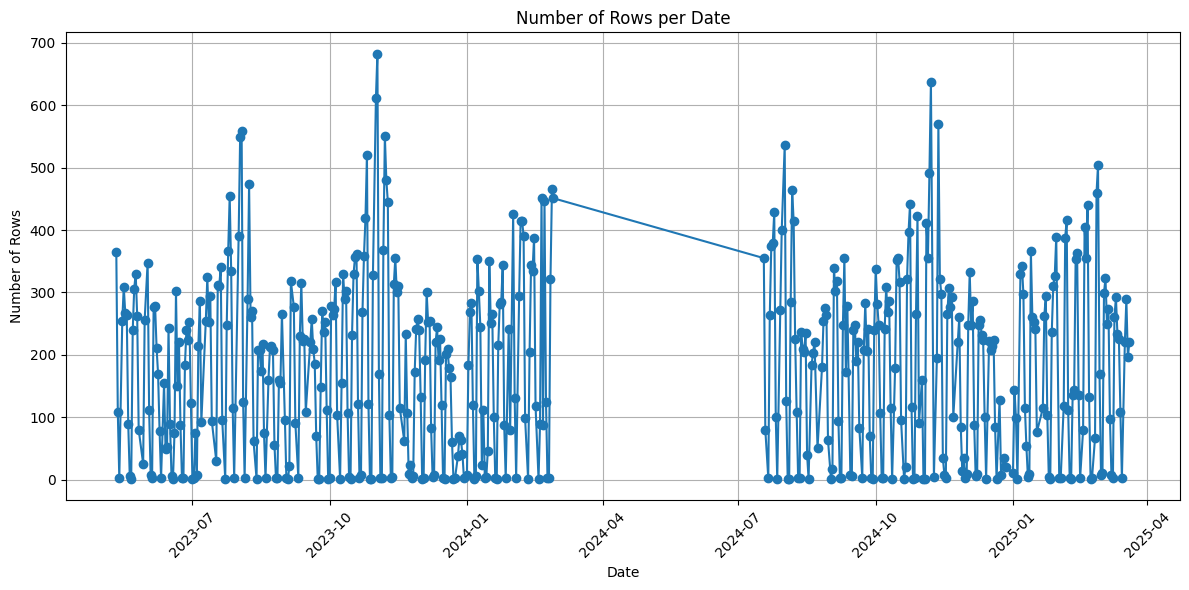

In [104]:
df2 = df.copy()
df2 = df2.iloc[: ,:]
df2['timestamp'] = pd.to_datetime(df2['timestamp'])

# Extract just the date part (drop time)
df2['date'] = df2['timestamp'].dt.date

# Count number of rows per date
date_counts = df2['date'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))
date_counts.plot(kind='line', marker='o')
plt.title('Number of Rows per Date')
plt.xlabel('Date')
plt.ylabel('Number of Rows')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

/var/folders/zl/pv06c9q126v0rv7mfvprvk180000gn/T/ipykernel_60514/3514367817.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_path.iloc[:,:] = df_path.iloc[:,:] - 1
/var/folders/zl/pv06c9q126v0rv7mfvprvk180000gn/T/ipykernel_60514/3514367817.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_path.iloc[:,:] = df_path.iloc[:,:].abs()


<Figure size 1200x600 with 0 Axes>

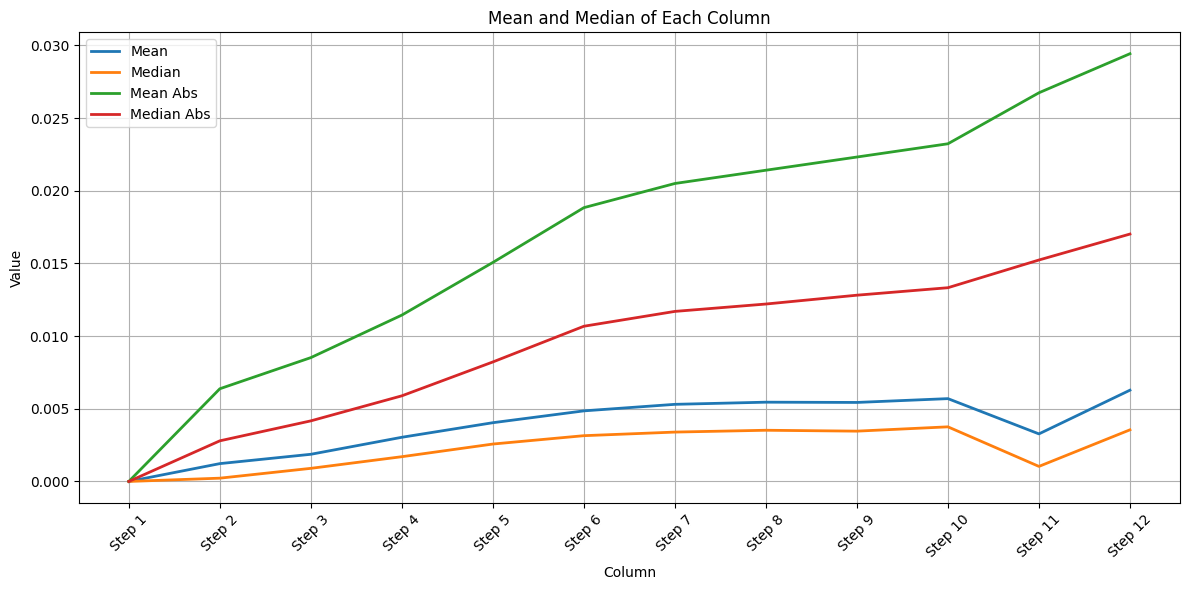

In [60]:
# print(df.columns.tolist())
# print(df.columns[44])
# print(df.columns[66])
df3 = df.copy()
df3.iloc[:, [44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66]] = df3.iloc[:, [44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66]].div(df3.iloc[:, 44], axis=0)
# print(df3.iloc[:,[44,46,48]].head())
df_path = df3.iloc[:, [44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66]] 
# Create a figure
plt.figure(figsize=(12, 6))

df_path.iloc[:,:] = df_path.iloc[:,:] - 1

mean_values = df_path.mean()
median_values = df_path.median()

df_path.iloc[:,:] = df_path.iloc[:,:].abs()

mean_values2 = df_path.mean()
median_values2 = df_path.median()

xtick_labels = ['Step 1', 'Step 2', 'Step 3', 'Step 4', 'Step 5', 'Step 6',
                'Step 7', 'Step 8', 'Step 9', 'Step 10', 'Step 11', 'Step 12']

# Plot
plt.figure(figsize=(12, 6))
plt.plot(mean_values, label='Mean', linewidth=2)
plt.plot(median_values, label='Median', linewidth=2)
plt.plot(mean_values2, label='Mean Abs', linewidth=2)
plt.plot(median_values2, label='Median Abs', linewidth=2)
# Labels and formatting
plt.xlabel('Time')
plt.ylabel('Price Change Since Market Open')
plt.legend()
plt.xticks(ticks=range(len(xtick_labels)), labels=xtick_labels, rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()
# # Plot each row as a line
# for i in range(min(len(df_path), 1000)):
#     plt.plot(df_path.columns, df_path.iloc[i], alpha=0.1)  # You can adjust alpha for transparency

# # Labels and formatting
# plt.title('Row-wise Line Plot')
# plt.xlabel('Column')
# plt.ylabel('Value')
# plt.xticks(rotation=45)
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [57]:
print(list(df["volScale"])[:100])
count = (df["volScale"] > 1.1).sum()
count = (df["volScale"] < 0.5).sum()
print(count/len(df))


[3.818140615497819, 1.3114494456680525, 17.944460720601548, 0.7531938962687794, 1.289725901641987, 1.2070134007689088, 0.5068285838615236, 1.5760822731517312, 2.8908440838725857, 1.2024519340902393, 2.9886585839357704, 1.096534628200156, 1.5034914848200773, 2.678826843420504, 2.582249169824287, 1.90486140765941, 1.317743868835021, 1.3003449848751676, 1.212494281164733, 0.4652730274541186, 2.0789616917625295, 2.025362984745122, 1.247146747747873, 1.2472287021679125, 1.0591252136933655, 1.9654816153339145, 1.1150742385204313, 1.1846751781362004, 0.8827739444454797, 1.3303745499958077, 1.8159058035510511, 1.0585563279854882, 0.8534868985249777, 0.8752622451315616, 3.818140615497819, 1.268582289864433, 1.767770101347777, 1.2385837093899008, 5.643207999272148, 0.7294170301599708, 1.0385587659616289, 3.018466420872879, 1.516978573486834, 1.3981063586303417, 1.7055474013565808, 1.5272337297403062, 1.4371958416271335, 0.2671596413252882, 1.5911100750111569, 1.491973656647987, 1.334472137429574